Creating a folder for source PDFs.

In [ ]:
import os

DST_DIR = "/content/pdfs"
os.makedirs(DST_DIR, exist_ok=True)

Mounted at /content/drive


Removing images from PDFs with PyMuPDF, which doesn't corrupt texts with specific fonts the way some online tools do.

In [ ]:
!pip install pymupdf

In [ ]:
import fitz
import os

def remove_images_from_pdf(input_pdf: str) -> None:
    doc = fitz.open(input_pdf)
    for page in doc:
        image_list = page.get_images()
        for img in image_list:
            xref = img[0]
            page.delete_image(xref)
    doc.save(input_pdf, garbage=3, deflate=True)
    doc.close()

def remove_images_in_folder(folder_path: str) -> None:
    for name in os.listdir(folder_path):
        path = os.path.join(folder_path, name)
        if os.path.isfile(path):
            remove_images_from_pdf(path)

remove_images_in_folder(DST_DIR)

Marker-pdf library installation for PDF2MD conversion.

In [ ]:
!python -m pip install -q --upgrade pip
!python -m pip install -q marker-pdf[full]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 72.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Setting device to cuda.

In [ ]:
import os
import torch

os.environ["TORCH_DEVICE"] = "cuda" if torch.cuda.is_available() else "cpu"

print("TORCH_DEVICE set to", os.environ["TORCH_DEVICE"])
print("torch version:", torch.__version__, "cuda available:", torch.cuda.is_available())

TORCH_DEVICE set to cuda
torch version: 2.10.0+cu128 cuda available: True


Disable image-processing tools, set Russian as the primary language, and turn off the additional LaTeX processing tool to speed up performance. In such mode one worker uses from 1.1 to 3.5 Gb for 300-page PDFs.

In [ ]:
%%bash
export DEFAULT_LANG=ru
export OCR_ENGINE=None
export ENABLE_TEXIFY=false
echo "$DEFAULT_LANG"
echo "$OCR_ENGINE"
echo "$ENABLE_TEXIFY"
marker "/content/pdfs" --output_format markdown --output_dir "/content/md" --workers 3 --disable_image_extraction

ru
None
false
Inferenced 145 pages in 331.62 seconds, for a throughput of 0.44 pages/sec for chunk 1/1


2026-03-25 19:17:46.418947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774466266.442066   45305 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774466266.449300   45305 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774466266.472630   45305 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774466266.472668   45305 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774466266.472672   45305 computation_placer.cc:177] computation placer alr

Manually remove private data from files. Put "@" symbol in the beginning of topic lines.

Importing modules for dataset creation.

In [1]:
from pathlib import Path
from hashlib import sha1
from collections import Counter
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from huggingface_hub import HfApi, login

In [2]:
md_dir = Path("/content/md")
out_dir = Path("/content/future_engineers_dataset")
out_dir.mkdir(parents=True, exist_ok=True)

HF login and dataset initialisation

In [3]:
token = 'YOUR_HF_TOKEN'
login(token=token)

api = HfApi()
username = api.whoami(token=token)["name"]
repo_id = f"{username}/future-engineers-dataset"

Extracting topics, texts, and year relations from MD-files.

In [42]:
records = []

for path in sorted(md_dir.glob("*.md")):
    year = int(path.stem.split("-")[0])
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()
    topic = None
    body = []

    for line in lines:
        if line.startswith("@"):
            if topic is not None:
                text = "\n".join(body)
                if text.strip():
                    uid = sha1(f"{year}\n{topic}\n{text}".encode("utf-8")).hexdigest()
                    records.append(
                        {
                            "id": uid,
                            "year": year,
                            "topic": topic,
                            "text": text
                        }
                    )
            topic = line[1:].strip()
            body = []
        else:
            if topic is not None:
                body.append(line)

    if topic is not None:
        text = "\n".join(body)
        if text.strip():
            uid = sha1(f"{year}\n{topic}\n{text}".encode("utf-8")).hexdigest()
            records.append(
                {
                    "id": uid,
                    "year": year,
                    "topic": topic,
                    "text": text
                }
            )

Sorting samples by year.

In [43]:
records = sorted(records, key=lambda x: (x["year"], x["topic"]))
print(len(records))

2193


Splitting to train/valid/test with 90/5/5 ratio

In [44]:
def split_name(uid):
    value = int(uid[:8], 16) % 100
    if value < 90:
        return "train"
    if value < 95:
        return "validation"
    return "test"

for row in records:
    row["split"] = split_name(row["id"])

In [45]:
df = pd.DataFrame(records)

Evaluating basic dataset stats.

In [46]:
year_counts = df["year"].value_counts().sort_index()
topic_lengths = df["topic"].str.len().tolist()
text_lengths = df["text"].str.len().tolist()

2019–2023 samples include comprehensive information such as methods, next steps, and tools. 2024 examples include only basic information like topic, aims, tasks, and results. There are fewer 2025 examples, but each is a full, unshortened text.

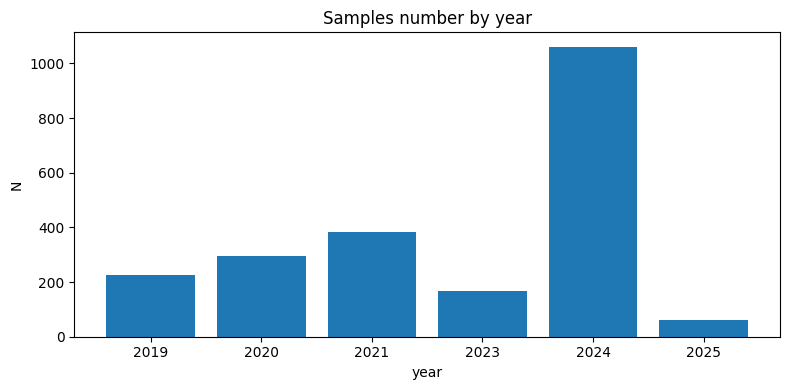

In [47]:
plt.figure(figsize=(8, 4))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.title("Samples number by year")
plt.xlabel("year")
plt.ylabel("N")
plt.tight_layout()
plt.savefig(out_dir / "year_counts.png", dpi=200)
plt.show()

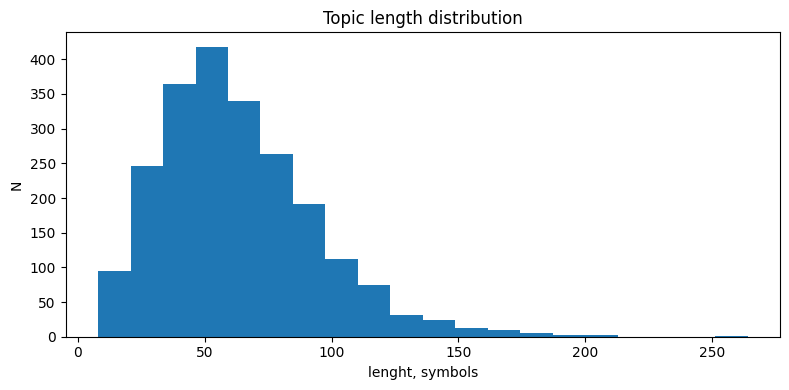

In [48]:
plt.figure(figsize=(8, 4))
plt.hist(topic_lengths, bins=20)
plt.title("Topic length distribution")
plt.xlabel("lenght, symbols")
plt.ylabel("N")
plt.tight_layout()
plt.savefig(out_dir / "topic_lengths.png", dpi=200)
plt.show()

Dataset includes long examples tens of thousands of characters long, generally from the year 2025.

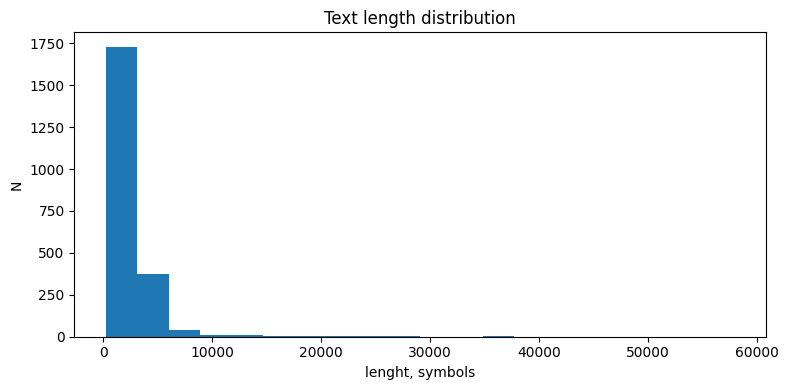

In [49]:
plt.figure(figsize=(8, 4))
plt.hist(text_lengths, bins=20)
plt.title("Text length distribution")
plt.xlabel("lenght, symbols")
plt.ylabel("N")
plt.tight_layout()
plt.savefig(out_dir / "text_lengths.png", dpi=200)
plt.show()

Short text distribution is more smooth containing about three peaks.

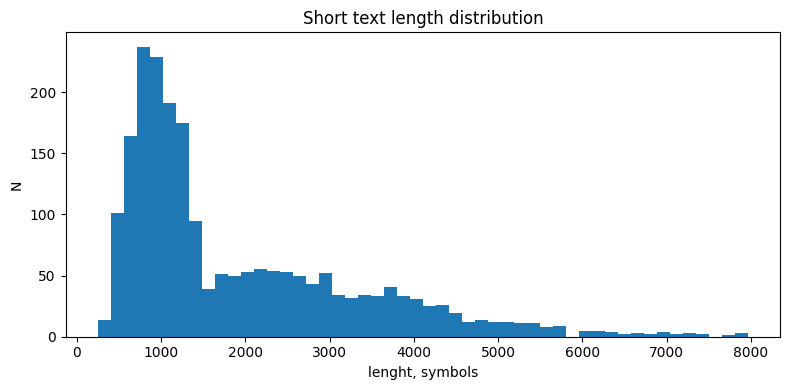

In [50]:
lt = df['text'].str.len()
short_text_lengths = df[lt <= 8000]['text'].str.len().tolist()

plt.figure(figsize=(8, 4))
plt.hist(short_text_lengths, bins=50)
plt.title("Short text length distribution")
plt.xlabel("lenght, symbols")
plt.ylabel("N")
plt.tight_layout()
plt.savefig(out_dir / "short_text_lengths.png", dpi=200)
plt.show()

The distribution is non-normal. Shapiro–Wilk p_value = 2.3e-41 << 0.05.

In [51]:
import scipy.stats as stats

arr = np.array(short_text_lengths)
shapiro_stat, shapiro_p = stats.shapiro(arr) if arr.size <= 5000 else (None, None)
print("Shapiro-Wilk:", shapiro_stat, shapiro_p)

Shapiro-Wilk: 0.8468462805879103 2.280118527459702e-41


Splitting samples.

In [52]:
splits = {
    "train": [r for r in records if r["split"] == "train"],
    "validation": [r for r in records if r["split"] == "validation"],
    "test": [r for r in records if r["split"] == "test"]
}

for split_name, rows in splits.items():
    with (out_dir / f"{split_name}.jsonl").open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(
                {
                    "id": row["id"],
                    "year": row["year"],
                    "topic": row["topic"],
                    "text": row["text"]
                },
                ensure_ascii=False
            ) + "\n")

Hugging Face dataset.

In [53]:
dataset = DatasetDict(
    {
        "train": Dataset.from_list(
            [{"id": r["id"], "year": r["year"], "topic": r["topic"], "text": r["text"]} for r in splits["train"]]
        ),
        "validation": Dataset.from_list(
            [{"id": r["id"], "year": r["year"], "topic": r["topic"], "text": r["text"]} for r in splits["validation"]]
        ),
        "test": Dataset.from_list(
            [{"id": r["id"], "year": r["year"], "topic": r["topic"], "text": r["text"]} for r in splits["test"]]
        )
    }
)

Commit.

In [54]:
dataset.push_to_hub(repo_id)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  99%|#########9| 3.88MB / 3.90MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  239kB /  239kB            

README.md:   0%|          | 0.00/583 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/pymlex/future-engineers-dataset/commit/78a63d661e6dbf6942897ff9f3ad3792041783c5', commit_message='Upload dataset', commit_description='', oid='78a63d661e6dbf6942897ff9f3ad3792041783c5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/pymlex/future-engineers-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='pymlex/future-engineers-dataset'), pr_revision=None, pr_num=None)